# Dataset Exploration

## 1. Import Libraries

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import os
data_dir = Path("../data/raw/Dataset (With Summer GT)")

## 2. Load Example Tree

In [15]:
summer_rgb_path = data_dir / "R01N01_Summer_RGB-12-40-50.png"
summer_depth_path = data_dir / "R01N01_Summer_D-12-40-50.png"
summer_gt_path = data_dir / "R01N01_Summer_GT-12-40-50.png"

winter_rgb_path = data_dir / "R01N01_Winter_RGB-11-23-49.png"
winter_depth_path = data_dir / "R01N01_Winter_D-11-23-49.png"

## 3. Inspect Image Properties

In [17]:
# creating array with images
summer_rgb = np.array(Image.open(summer_rgb_path))
summer_depth = np.array(Image.open(summer_depth_path))
summer_gt = np.array(Image.open(summer_gt_path))

winter_rgb = np.array(Image.open(winter_rgb_path))
winter_depth = np.array(Image.open(winter_depth_path))


print("Summer RGB:", summer_rgb.shape, summer_rgb.dtype)
print("Summer depth:", summer_depth.shape, summer_depth.dtype)
print("Summer GT:", summer_gt.shape, summer_gt.dtype)

print("Winter RGB:", winter_rgb.shape, winter_rgb.dtype)
print("Winter depth:", winter_depth.shape, winter_depth.dtype)

print("Summer depth min:", summer_depth.min())
print("Summer depth max:", summer_depth.max())

print("GT unique values:", np.unique(summer_gt))

Summer RGB: (480, 640, 3) uint8
Summer depth: (480, 640, 3) uint8
Summer GT: (256, 256) uint8
Winter RGB: (480, 640, 3) uint8
Winter depth: (480, 640, 3) uint8
Summer depth min: 0
Summer depth max: 169
GT unique values: [  0 255]


## 4. Visualise RGB, Depth and Ground Truth

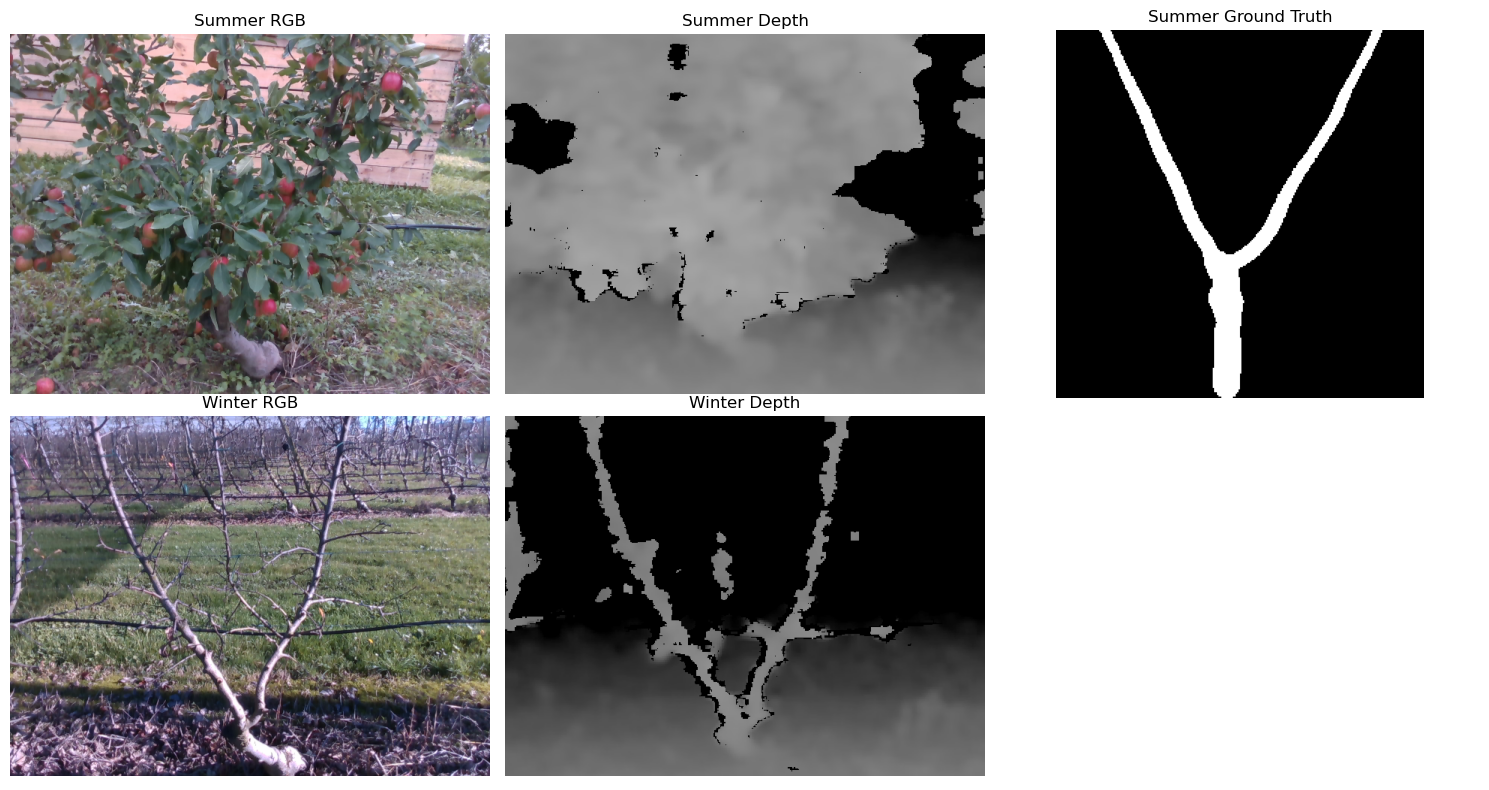

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(summer_rgb)
axes[0, 0].set_title("Summer RGB")

axes[0, 1].imshow(summer_depth, cmap="gray")
axes[0, 1].set_title("Summer Depth")

axes[0, 2].imshow(summer_gt, cmap="gray")
axes[0, 2].set_title("Summer Ground Truth")

axes[1, 0].imshow(winter_rgb)
axes[1, 0].set_title("Winter RGB")

axes[1, 1].imshow(winter_depth, cmap="gray")
axes[1, 1].set_title("Winter Depth")

axes[1, 2].axis("off")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Analyse Depth Data

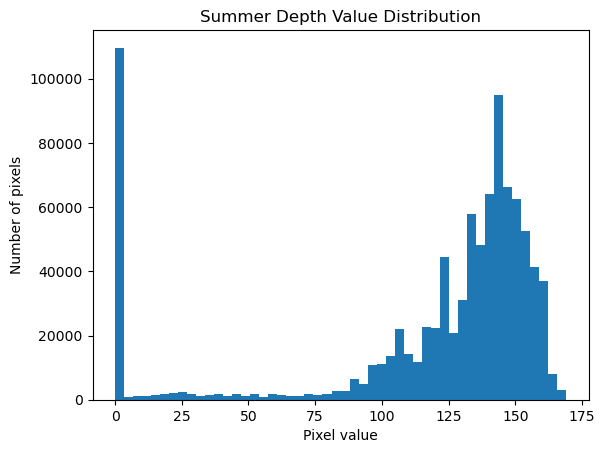

In [19]:
plt.hist(summer_depth.flatten(), bins=50)
plt.xlabel("Pixel value")
plt.ylabel("Number of pixels")
plt.title("Summer Depth Value Distribution")
plt.show()

## 6. Analyse Ground Truth

## 7. Dataset Structure and Pairing

In [41]:
class TreeDataset:
    def __init__(self, data_dir):
        self.data_dir = Path(data_dir)

        # Get all PNG files
        self.file_list = list(self.data_dir.glob("*.png"))

        # Find unique tree IDs
        self.tree_names = sorted(
            set(file.name[:6] for file in self.file_list)
        )

        self.number_of_images = len(self.file_list)
        self.number_of_trees = len(self.tree_names)

dataset = TreeDataset(data_dir)

print(dataset.number_of_images)
print(dataset.number_of_trees)
print(dataset.tree_names)

class Tree:
    def __init__(self, tree_id, data_dir):
        self.tree_id = tree_id
        self.data_dir = Path(data_dir)

        self.files = list(
            self.data_dir.glob(f"{tree_id}_*.png")
        )

        self.summer_rgb_path = self.find_file("Summer_RGB")
        self.summer_depth_path = self.find_file("Summer_D")
        self.summer_gt_path = self.find_file("Summer_GT")

        self.winter_rgb_path = self.find_file("Winter_RGB")
        self.winter_depth_path = self.find_file("Winter_D")

    def find_file(self, keyword):
        for file in self.files:
            if keyword in file.name:
                return file

        return None

tree = Tree("R01N01", data_dir)

print(tree.summer_rgb_path)
print(tree.summer_depth_path)
print(tree.summer_gt_path)
print(tree.winter_rgb_path)
print(tree.winter_depth_path)

2810
562
['R01N01', 'R01N02', 'R01N03', 'R01N04', 'R01N05', 'R01N06', 'R01N07', 'R01N08', 'R01N09', 'R01N10', 'R01N11', 'R01N12', 'R01N13', 'R01N14', 'R01N15', 'R01N16', 'R01N17', 'R01N18', 'R01N19', 'R01N20', 'R01N21', 'R01N22', 'R01N23', 'R01N24', 'R01N25', 'R01N26', 'R01N27', 'R01N28', 'R01N29', 'R01N30', 'R01N31', 'R01N32', 'R01N33', 'R01N34', 'R01N35', 'R01N36', 'R01N37', 'R01N38', 'R01N39', 'R01N40', 'R01N41', 'R01N42', 'R01N43', 'R01N44', 'R02N01', 'R02N02', 'R02N03', 'R02N04', 'R02N05', 'R02N06', 'R02N07', 'R02N08', 'R02N09', 'R02N10', 'R02N11', 'R02N12', 'R02N13', 'R02N14', 'R02N15', 'R02N16', 'R02N17', 'R02N18', 'R02N19', 'R02N20', 'R02N21', 'R02N22', 'R02N23', 'R02N24', 'R02N25', 'R02N26', 'R02N27', 'R02N28', 'R02N29', 'R02N30', 'R02N31', 'R02N32', 'R02N33', 'R02N34', 'R02N35', 'R02N36', 'R02N37', 'R02N38', 'R02N39', 'R02N40', 'R02N41', 'R02N42', 'R02N43', 'R03N01', 'R03N02', 'R03N03', 'R03N04', 'R03N05', 'R03N06', 'R03N07', 'R03N08', 'R03N09', 'R03N10', 'R03N11', 'R03N12', 